<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</center></font>
<center><font size=6>Machine Learning - Week 3</font></center>

<center><img src="https://images.unsplash.com/photo-1620714223084-8fcacc6dfd8d?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&auto=format&fit=crop&w=871&q=80" width="720"></center>

<center><font size=6>Credit Card Customer Segmentation</font></center>

## Installing and Importing the Necessary libraries

In [1]:
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 plotly==5.24.1 scikit-learn==1.6.1 -q

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [47]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.spatial.distance import cdist

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [6]:
# loading the dataset
customer_data = pd.read_csv("https://raw.githubusercontent.com/bootstrap0/machine-learning/refs/heads/main/NutrientCompositionDataset.csv")

In [7]:
# copying the data to another variable to avoid any changes to original data
df = customer_data.copy()

## Data Overview

### Displaying the first few rows of the data

In [8]:
# viewing the first 5 rows of the data
df.head()

,S.No,Protein,Fat,vitaminC,Fibre,Product
0,1,0.452369,1.170926,1.079271,1.702960,"Amaranth leaves, cooked, boiled, drained, with..."
1,2,2.321087,0.706856,0.350088,0.658249,Bacon and beef sticks
2,3,0.884554,1.186571,2.428544,1.984562,"Apples, frozen, unsweetened, unheated (Include..."
3,4,0.715501,0.577599,0.270925,0.369266,"Alcoholic beverage, beer, light, BUD LIGHT"
4,5,0.132610,0.544521,0.116884,0.557309,"Alcoholic beverage, daiquiri, canned"


In [15]:
# fixing column names
df.drop(columns=["Product"], inplace=True)

### Checking the shape of the dataset

In [ ]:
df.shape

* The dataset has 660 rows and 7 columns

### Checking the data types of the columns for the dataset.

In [ ]:
# checking datatypes and number of non-null values for each column
df.info()

- All the columns in the data are numeric.

### Checking for missing values

In [ ]:
# checking for missing values
df.isnull().sum()

- There are no missing values in the data.

### Checking for duplicate values

In [ ]:
# checking the number of unique values in each column
df.nunique()

- There are less unique values in the *Customer_Key* column than the number of observations in the data. This means that there are duplicate values in the column.

Let's look at the duplicate values in the *Customer_Key* column closely.

In [ ]:
# getting the count for each unique value in Customer_Key
data_grouped = df.groupby("Customer_Key").count()

for i in data_grouped.loc[data_grouped.Sl_No >= 2].index:
    display(df.loc[df.Customer_Key == i])

**Observations**

- There are 5 duplicate customer entries in the data.
- Most of these duplicates look like customer profile changes.
- There is no need to delete these records as these are actual occurrences at some point in the time.

We will drop the *Sl_No* and *Customer_Key* as they do not add any value to the analysis.

In [ ]:
df.drop(columns=["Sl_No", "Customer_Key"], inplace=True)

### Checking the Statistical Summary

In [16]:
# Let's look at the statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
S.No,1746.0,873.500000,504.171102,1.000000,437.250000,873.500000,1309.750000,1746.000000
Protein,1746.0,0.922470,0.627128,0.000128,0.435853,0.813025,1.295106,4.016890
Fat,1746.0,0.900091,0.634617,0.000267,0.394784,0.804687,1.298988,3.979364
vitaminC,1746.0,0.900146,0.623847,0.000029,0.419103,0.796290,1.280870,4.013322
Fibre,1746.0,0.900830,0.626875,0.002579,0.389124,0.820783,1.295732,3.570331


## Exploratory Data Analysis

The below functions need to be defined to carry out the EDA.

In [41]:

# dropping S.No column

df.drop("S.No", axis=1, inplace=True)

# IQR of Protein column

df.Protein.quantile(0.75) - df.Protein.quantile(0.25)

np.float64(0.8592526325000001)

Number of Clusters: 15 	Average Distortion: 0.6996524054301163


ValueError: x and y must have same first dimension, but have shapes (15,) and (1,)

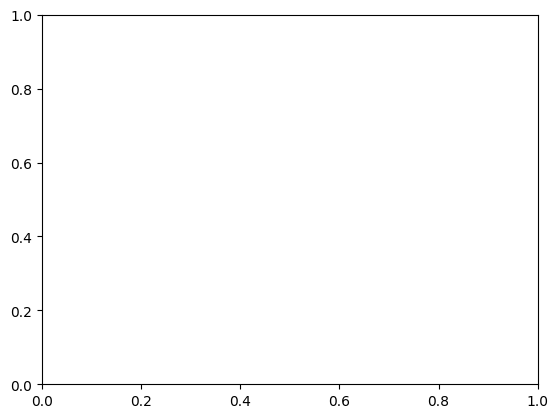

In [48]:
# scaling the data before clustering
scaler = StandardScaler()
subset_scaled_df = df.iloc[:, :-1].copy()
subset_scaled_df.iloc[:, :] = scaler.fit_transform(subset_scaled_df.iloc[:, :])
subset_scaled_df.head()

# creating a copy of the scaled dataframe

k_means_df = subset_scaled_df.copy()

# elbow plot

clusters = range(1, 16)
meanDistortions = []

for k in clusters:
  model = KMeans(n_clusters=k, random_state=1)
  model.fit(subset_scaled_df)
  prediction = model.predict(k_means_df)
  distortion = (
    sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis=1)) / k_means_df.shape[0]
  )

meanDistortions.append(distortion)

print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

For n_clusters = 2, the silhouette score is 0.3115520390991963)
For n_clusters = 3, the silhouette score is 0.29944918156977)
For n_clusters = 4, the silhouette score is 0.25588154059573703)
For n_clusters = 5, the silhouette score is 0.2508868002630709)
For n_clusters = 6, the silhouette score is 0.2651525891539612)
For n_clusters = 7, the silhouette score is 0.2448740464838995)
For n_clusters = 8, the silhouette score is 0.23965662254020842)
For n_clusters = 9, the silhouette score is 0.24048588480445085)
For n_clusters = 10, the silhouette score is 0.2405280816903639)
For n_clusters = 11, the silhouette score is 0.24248395073318274)
For n_clusters = 12, the silhouette score is 0.2331070705131051)
For n_clusters = 13, the silhouette score is 0.22938673040687485)
For n_clusters = 14, the silhouette score is 0.23603485457581608)
For n_clusters = 15, the silhouette score is 0.24261284852277853)


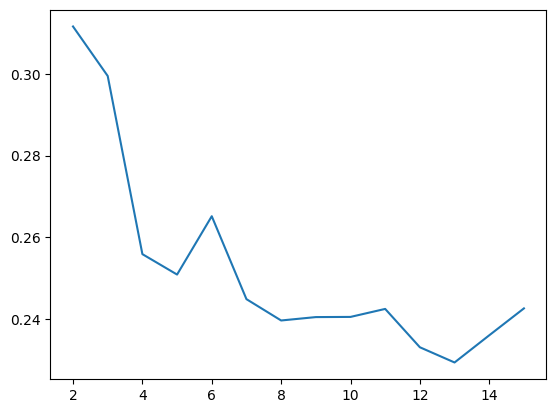

In [49]:
sil_score = []
cluster_list = range(2, 16)
for n_clusters in cluster_list:
 clusterer = KMeans(n_clusters=n_clusters, random_state=1)
 preds = clusterer.fit_predict((subset_scaled_df))
 score = silhouette_score(k_means_df, preds)
 sil_score.append(score)
 print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))
plt.plot(cluster_list, sil_score)
plt.show()

In [50]:
# fitting K-means model
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(k_means_df)


# adding kmeans cluster labels to the original and scaled dataframes
k_means_df["KM_segments"] = kmeans.labels_
df2 = df.copy()
df2["KM_segments"] = kmeans.labels_


# cluster profiling
km_cluster_profile = df2.groupby("KM_segments").mean()
km_cluster_profile["count_in_each_segment"] = (
 df2.groupby("KM_segments")["Protein"].count().values
)
km_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Protein,Fat,vitaminC,Fibre,count_in_each_segment
KM_segments,,,,,
0,0.612190,0.585241,0.535862,0.753369,811
1,0.780966,0.737337,1.691389,1.162701,440
2,1.556609,1.560607,0.793656,0.909652,495


In [ ]:
import pandas as pd
from scipy.stats import zscore
from sklearn.cluster import KMeans

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
df_scaled = df[features].apply(zscore)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)
centroids = kmeans.cluster_centers_

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
X = df[features]

# Assuming X is your data
ssd = []
K = [2, 3, 4, 5]

for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    ssd.append(kmeans.inertia_)

plt.plot(K, ssd, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
df_clustering = df[features]

kmeans = KMeans(n_clusters=3, random_state=42)
df_clustering['cluster'] = kmeans.fit_predict(df_clustering)

grouped_df = df_clustering.groupby('cluster')

df_clustering.boxplot(by='cluster')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
X = df[features]

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(X_stand)
wcss = kmeans.inertia_

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
X = df[features]

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(X_stand)

silhouette_score_value = silhouette_score(X_stand, kmeans.labels_)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
X = df[features]

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
clusters = range(2, 11)
WCSS = []
for k in clusters:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_stand)
    WCSS.append(kmeans.inertia_)

optimal_k = WCSS.index(min(WCSS)) + 2

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
X = df[features]

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
clusters = range(2, 11)
Silhouette = []
for k in clusters:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_stand)
    Silhouette.append(silhouette_score(X_stand, kmeans.labels_))

optimal_k = Silhouette.index(max(Silhouette)) + 2

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
X = df[features]

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
clusters = range(2, 11)
WCSS = []
for k in clusters:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_stand)
    WCSS.append(kmeans.inertia_)

plots = plt.plot(clusters, WCSS, 'bx-')
optimal_k = 3

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement', 'weight', 'acceleration']
X = df[features]

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(X_stand)

df['Cluster'] = kmeans.labels_

# Visualize clusters
plot = sns.scatterplot(data=df,x='mpg',y='displacement',hue='Cluster',palette='viridis',alpha=0.7)
plot.set_title('Cluster of Points')
plot.set_xlabel('mpg')
plot.set_ylabel('displacement')

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

df = pd.read_csv('data.csv')

# Write your code below
features = ['mpg', 'displacement']
X = df[features]

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(X_stand)

df['Cluster'] = kmeans.labels_
centroids = kmeans.cluster_centers_

# Visualize clusters and centroids
plot_1 = sns.scatterplot(x=X_stand[:, 0], y=X_stand[:, 1], c=df['Cluster'],alpha=0.7)
plot_2 = sns.scatterplot(x=centroids[:, 0], y=centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plot_1.set_title('Clusters with Centroids')
plot_1.set_xlabel('mpg')
plot_1.set_ylabel('displacement')

In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to build a linear regression model
from sklearn.linear_model import LinearRegression
# to build decision tree model
from sklearn.tree import DecisionTreeClassifier

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

df = pd.read_csv('https://raw.githubusercontent.com/bootstrap0/machine-learning/refs/heads/main/backpain.csv')

#sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")

# Assuming your dataframe is named 'df' and the column is 'Status'
df['Status'] = df['Status'].map({'Abnormal': 1, 'Normal': 0})

# Define features (X) and target (y)
X = df.drop(columns=['Status'])
y = df['Status']


# Split the data into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)
# This outputs the proportions (percentages as decimals) for each class
y_test.value_counts(normalize=True)

# creating an instance of the decision tree model
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

# predicting using the independent variables
y_pred = model.predict(X_test)

recall = recall_score(y_test, y_pred)  # to compute Recall
print("Recall:", recall)

precision = precision_score(y_test, y_pred)  # to compute Precision
print("Precision:", precision)

def plot_confusion_matrix(model, predictors, target):

    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

plot_confusion_matrix(model, X_test, y_test)

from sklearn.linear_model import LogisticRegression
# Fit the model on training set
model = LogisticRegression(random_state=1)
lg = model.fit(X_train,y_train)

# predicting on the training set
y_train_pred = lg.predict(X_train)
# checking the recall score
recall_score(y_train,y_train_pred)

model = LogisticRegression(solver="liblinear", random_state=1)
model.fit(X_train, y_train)
#predict on test
y_predict = model.predict(X_test)
# checking the recall score
recall_score(y_test,y_predict)


# importing confusion matrix
from sklearn.metrics import confusion_matrix

# plotting confusion matrox
sns.heatmap(confusion_matrix(y_test,y_predict),annot=True,fmt='.1f')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

,proportion
Status,
1,0.709677
0,0.290323
